# Why AES-ECB mode is unsafe

This notebook is the runnable companion to [`docs/ecb-mode-unsafe.md`](../docs/ecb-mode-unsafe.md).
Every attack below runs against a real AES-ECB oracle in this process — nothing here is
a diagram or a claim without code behind it.

ECB has exactly two root causes of failure:

1. **Determinism** — identical plaintext blocks always produce identical ciphertext blocks under the same key.
2. **No integrity / no chaining** — blocks are encrypted independently, so they can be reordered, spliced, or dropped with no decryption error.

Four vectors below are each a direct consequence of one or both root causes.

In [1]:
import os
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from ecb_lab.crypto_helpers import aes_ecb_encrypt, split_blocks
from ecb_lab.detection import has_repeated_blocks, likely_ecb_encryptor
from ecb_lab.pattern_leakage import encrypt_image_under_each_mode, generate_sample_bitmap
from ecb_lab.oracle_attack import recover_secret, make_suffix_oracle
from ecb_lab.cut_and_paste import ProfileService, forge_admin_token
from ecb_lab.crypto_helpers import aes_gcm_encrypt, aes_gcm_decrypt
from cryptography.exceptions import InvalidTag

print("Setup OK")

Setup OK


## Vector 1 — Pattern & structure leakage

Encrypt a structured bitmap under ECB, CBC, and GCM with the same key, then rebuild each
ciphertext as an image of the same dimensions. This proves the point directly: the
outline of the source image survives ECB encryption because uniform regions of the
bitmap are made of identical 16-byte blocks, and ECB maps identical plaintext blocks to
identical ciphertext blocks every time.

**What this proves:** ECB leaks the *structure* of multi-block plaintext, visually and
without any statistical analysis. **What this does not prove:** that CBC/GCM are safe
under all conditions — CBC still needs a fresh random IV per message (shown later), and
this single image says nothing about GCM's nonce-reuse risk.

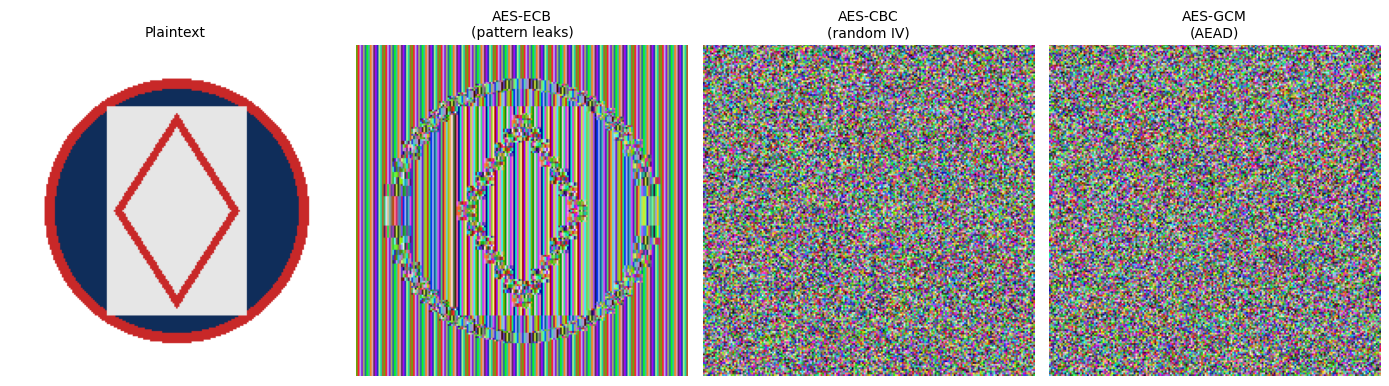

ECB ciphertext has repeated 16-byte blocks: True
CBC ciphertext has repeated 16-byte blocks: False
GCM ciphertext has repeated 16-byte blocks: False


In [2]:
key = os.urandom(16)
img = generate_sample_bitmap(width=192, height=192)
results = encrypt_image_under_each_mode(img, key)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, name, title in zip(
    axes,
    ["original", "ecb", "cbc", "gcm"],
    ["Plaintext", "AES-ECB\n(pattern leaks)", "AES-CBC\n(random IV)", "AES-GCM\n(AEAD)"],
):
    ax.imshow(results[name])
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("ecb_pattern_leakage.png", dpi=120, bbox_inches="tight")
plt.show()

print("ECB ciphertext has repeated 16-byte blocks:", has_repeated_blocks(results["ecb"].tobytes()))
print("CBC ciphertext has repeated 16-byte blocks:", has_repeated_blocks(results["cbc"].tobytes()))
print("GCM ciphertext has repeated 16-byte blocks:", has_repeated_blocks(results["gcm"].tobytes()))

## Vector 2 — Equality inference (the Adobe 2013 pattern)

Adobe's 2013 breach exposed roughly 153 million password records encrypted (not hashed)
in ECB mode with what researchers identified as 3DES (inferred from the 8-byte block size,
not confirmed by Adobe), with no per-user salt. Because ECB is deterministic, two users
with the same password produced byte-identical ciphertext — so anyone with the leaked
database could count duplicate ciphertext values and rank the most common passwords
without ever decrypting anything, then confirm guesses using the plaintext password
hints Adobe also stored.

The demo below reproduces the *mechanism*, not the breach: a small simulated password
table, encrypted independently per user under one ECB key, where duplicate ciphertext
reveals duplicate passwords with zero decryption.

In [3]:
key = os.urandom(16)
users = {
    "alice":   "sunshine1",
    "bob":     "letmein123",
    "carol":   "sunshine1",   # same password as alice
    "dave":    "qwerty2024",
    "erin":    "letmein123",  # same password as bob
}

ciphertext_by_user = {user: aes_ecb_encrypt(key, pw.encode()) for user, pw in users.items()}

# Group users by identical ciphertext -- this is the entire attack. No key, no decryption.
groups = {}
for user, ct in ciphertext_by_user.items():
    groups.setdefault(ct, []).append(user)

print("Users clustered by ciphertext equality (no decryption performed):")
for ct, members in groups.items():
    if len(members) > 1:
        print(f"  {members} share a password (ciphertext {ct[:6].hex()}...)")

Users clustered by ciphertext equality (no decryption performed):
  ['alice', 'carol'] share a password (ciphertext cb3fb0a00a47...)
  ['bob', 'erin'] share a password (ciphertext ed105c7dcd78...)


## Detecting ECB mode

Two independent ways to tell whether a system is using ECB, matching what an attacker
*and* a defender doing a security review would each reach for.

**Black-box (ciphertext only):** feed the same 16-byte block through the target three
times in a row. If any two output blocks are identical, the target is ECB (or something
equally broken) — this is Cryptopals Set 1 Challenge 8's technique, generalized from
"find the ECB file" to "test any encryption oracle." No source access needed.

**White-box (source/config):** ECB is often not a deliberate choice. Several libraries
default to it — see `ecb_lab.detection.KNOWN_ECB_DEFAULT_FOOTGUNS` for verified real
instances, including Java's `Cipher.getInstance("AES")` silently resolving to
`AES/ECB/PKCS5Padding`, found in production in MEGA, bilibili's Android client, and
India's Aarogya Setu contact-tracing app. A grep pass with
`ecb_lab.detection.STATIC_GREP_PATTERNS` catches this class of bug before it ships.

In [4]:
ecb_key = os.urandom(16)
cbc_key = os.urandom(16)

candidates = {
    "service_A (unknown mode)": lambda pt, k=ecb_key: aes_ecb_encrypt(k, pt),
    "service_B (unknown mode)": lambda pt, k=cbc_key: __import__("ecb_lab.crypto_helpers", fromlist=["aes_cbc_encrypt"]).aes_cbc_encrypt(k, pt)[1],
}

for name, encrypt_fn in candidates.items():
    verdict = likely_ecb_encryptor(encrypt_fn)
    print(f"{name}: {'ECB' if verdict else 'not ECB'}")

service_A (unknown mode): ECB
service_B (unknown mode): not ECB


## Vector 3 — Chosen-plaintext byte-at-a-time recovery

A service that computes `AES-ECB(attacker_input + secret, key)` — for example, an
endpoint that appends a session secret to whatever the caller submits before encrypting
— leaks the secret one byte per (up to) 256 oracle queries, using only the ciphertext.
The attacker never sees the key. This is Cryptopals Set 2 Challenge 12.

**What this proves:** the secret is fully recoverable through the ciphertext side
channel alone. **What this does not prove:** this exact technique works unmodified if
the oracle prepends a *random, per-call* prefix before attacker input — that needs the
block-boundary alignment step from Cryptopals Challenge 14 (`ecb_lab.oracle_attack`
does not implement the prefixed variant; only the direct-suffix case shown here).

In [5]:
secret = b"sk_live_51H8x...redacted_api_key"
oracle = make_suffix_oracle(secret)

recovered = recover_secret(oracle)
print("Recovered secret:", recovered)
assert recovered == secret
print("Matches the real secret:", recovered == secret)

Recovered secret: b'sk_live_51H8x...redacted_api_key'
Matches the real secret: True


## Vector 4 — Block malleability: cut-and-paste privilege escalation

With no chaining and no authentication tag, ciphertext blocks are portable. If an
attacker can get *any* chosen plaintext encrypted under the target's key — here, by
controlling their own `email` field — they can splice a ciphertext block that decrypts
to `role=admin` onto a legitimately issued token, and the server accepts it. This is
Cryptopals Set 2 Challenge 13.

In [6]:
service = ProfileService()

legit_token = service.issue_token("attacker@example.com")
print("Legitimate token role:", service.role_for_token(legit_token))

forged_token = forge_admin_token(service)
print("Forged token role:    ", service.role_for_token(forged_token))
assert service.role_for_token(forged_token) == "admin"


Legitimate token role: user
Forged token role:     admin


## Defensive control: the same scenario under AES-GCM

Re-run the token scheme with AES-GCM instead of AES-ECB. GCM adds a fresh nonce per
message (breaking determinism, defeating vectors 1-3) and an authentication tag that is
verified *before* the plaintext is trusted (defeating vector 4 — tampered ciphertext
raises `InvalidTag` instead of silently decrypting to a modified role).

In [7]:
gcm_key = os.urandom(32)

def issue_gcm_token(email: str) -> tuple:
    profile = f"email={email}&uid=1000&role=user".encode()
    return aes_gcm_encrypt(gcm_key, profile)

def role_for_gcm_token(nonce: bytes, ct: bytes) -> str:
    plaintext = aes_gcm_decrypt(gcm_key, nonce, ct)
    fields = dict(p.split("=", 1) for p in plaintext.decode().split("&"))
    return fields["role"]

nonce, ct = issue_gcm_token("attacker@example.com")
print("Legitimate GCM token role:", role_for_gcm_token(nonce, ct))

# Attempt the same block-splicing idea: flip a byte to try to forge role=admin.
tampered = bytearray(ct)
tampered[-1] ^= 0xFF
try:
    role_for_gcm_token(nonce, bytes(tampered))
    print("Forgery succeeded (should not happen)")
except InvalidTag:
    print("Tamper attempt rejected: InvalidTag raised before any plaintext was trusted.")

Legitimate GCM token role: user
Tamper attempt rejected: InvalidTag raised before any plaintext was trusted.


## Residual risk

Switching to GCM defeats all four vectors above, but introduces a new failure mode of
its own: **nonce reuse**. Encrypting two different messages under the same (key, nonce)
pair with AES-GCM breaks confidentiality and can let an attacker forge the authentication
tag outright — this is not a theoretical footnote, it is the mechanism behind real GCM
nonce-reuse breaks. `ecb_lab.crypto_helpers.aes_gcm_encrypt` generates a fresh random
96-bit nonce on every call specifically to avoid this; a from-scratch implementation must
preserve that property, not just "use GCM."

Verification for a deployed fix: rerun `has_repeated_blocks` against production
ciphertext samples (should return `False` for GCM/CBC output where it returned `True`
under ECB) and confirm that a crafted tamper attempt raises `InvalidTag` rather than
decrypting.